In [13]:
import os
import pandas as pd
import cv2
from tqdm import tqdm

In [2]:
import os
os.listdir('/kaggle/input')

['datasets']

# 1. Image Preprocessing

In [3]:
from skimage.morphology import remove_small_objects, disk, binary_dilation
from skimage.filters import frangi
from skimage.exposure import rescale_intensity
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

def bone_window(img):
    """Apply bone windowing with percentile-based contrast stretching"""
    img = img.astype(np.float32)
    p1, p99 = np.percentile(img, (0.5, 99.5))
    img = np.clip(img, p1, p99)
    if p99 - p1 > 0:
        img = (img - p1) / (p99 - p1)
    return img

def clahe(img):
    """Apply Contrast Limited Adaptive Histogram Equalization"""
    img8 = (img * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img8) / 255.0

def enhance_bones(img, bone_type='general'):
    """Apply Frangi filter to enhance bone structures"""
    if bone_type == 'fine':
        sigmas = np.arange(0.5, 4, 0.5)  # Smaller bones
    elif bone_type == 'thick':
        sigmas = np.arange(2, 10, 1)  # Larger bones
    else:
        sigmas = np.arange(0.5, 8, 0.5)  # Default - wider range

    v = frangi(img, sigmas=sigmas, black_ridges=False, alpha=0.5, beta=0.5, gamma=15)

    # More aggressive rescaling
    v = rescale_intensity(v, in_range='image', out_range=(0, 1))

    # Apply gamma correction to boost the response
    v = np.power(v, 0.7)

    return v

def make_bone_mask(bone_map, method='adaptive', percentile=50, min_size=500):
    """Create binary mask of bone regions"""
    if method == 'adaptive':
        # Use a much lower threshold - 50th percentile instead of 75th
        t = np.percentile(bone_map[bone_map > 0], percentile) if np.any(bone_map > 0) else 0
        mask = bone_map > t
    elif method == 'otsu':
        bone_8bit = (bone_map * 255).astype(np.uint8)
        # Apply Otsu on non-zero values only
        non_zero = bone_8bit[bone_8bit > 0]
        if len(non_zero) > 0:
            thresh_val = cv2.threshold(non_zero, 0, 255, cv2.THRESH_OTSU)[0]
            # Use a fraction of Otsu threshold for more sensitive detection
            mask = bone_8bit > (thresh_val * 0.5)
        else:
            mask = bone_8bit > 0
    else:  # 'percentile'
        t = np.percentile(bone_map, percentile)
        mask = bone_map > t

    # Remove very small objects but keep more regions
    if np.any(mask):
        mask = remove_small_objects(mask, min_size)
        # Slight dilation to connect nearby bone regions
        mask = binary_dilation(mask, disk(2))

    return mask

def process_xray(img_path,
                 bone_type='general',
                 mask_method='adaptive',
                 mask_percentile=50,
                 min_object_size=500):

    # Read image
    original_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if original_img is None:
        return None

    # Validate image size
    if original_img.shape[0] < 100 or original_img.shape[1] < 100:
        print(f" Image too small: {img_path}")
        return None

    # Processing pipeline - simplified for better results
    processed_img = bone_window(original_img)
    processed_img = clahe(processed_img)

    # Apply Frangi filter
    bones = enhance_bones(processed_img, bone_type=bone_type)

    # Create mask with more sensitive thresholding
    mask = make_bone_mask(bones, method=mask_method,
                         percentile=mask_percentile,
                         min_size=min_object_size)

    bone_only = bones * mask

    return {
        'original': original_img,
        'bones': bones,
        'bone_only': bone_only,
        'mask': mask,
        'processed': processed_img
    }


# 2. Build Preprocessed Dataset

In [ ]:
import os
from pathlib import Path
import cv2
import pandas as pd
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm



BASE_PATH = "/kaggle/input/datasets/farahbenrejab/mura-dataset/MURA-v1.1"
OUTPUT_DIR = "/kaggle/working/MURA_FINGERS_PREPROCESSED"

os.makedirs(OUTPUT_DIR, exist_ok=True)

=
train_df = pd.read_csv(
    os.path.join(BASE_PATH, "train_labeled_studies.csv"),
    header=None,
    names=["study_path", "label"]
)

valid_df = pd.read_csv(
    os.path.join(BASE_PATH, "valid_labeled_studies.csv"),
    header=None,
    names=["study_path", "label"]
)


train_df = train_df[train_df["study_path"].str.contains("XR_FINGER")].reset_index(drop=True)
valid_df = valid_df[valid_df["study_path"].str.contains("XR_FINGER")].reset_index(drop=True)

print(f"Train for finger studies: {len(train_df)}")
print(f"Valid finger studies: {len(valid_df)}")


def process_study(args):
    row, split = args
    saved_files = []

    study_path = row["study_path"]

    study_dir = os.path.join(
        BASE_PATH,
        study_path.replace("MURA-v1.1/", "")
    )

    if not os.path.exists(study_dir):
        print(f"Missing study folder: {study_dir}")
        return saved_files

    for img_name in os.listdir(study_dir):
        if not img_name.lower().endswith(".png"):
            continue

        img_path = os.path.join(study_dir, img_name)

        
        enhanced_dict = process_xray(
            img_path,
            bone_type="general",
            mask_method="adaptive",
            mask_percentile=50,
            min_object_size=500
        )

        if enhanced_dict is None:
            continue

        processed = enhanced_dict["processed"]

       
        if np.max(processed) > 0:
            processed = (processed / np.max(processed) * 255).astype(np.uint8)
        else:
            processed = (processed * 255).astype(np.uint8)

        processed = cv2.resize(processed, (224, 224))

        relative_study_path = study_path.replace("MURA-v1.1/", "")

        out_path = (
            Path(OUTPUT_DIR)
            / "MURA-v1.1"
            / split
            / relative_study_path
            / img_name
        )

        out_path.parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(out_path), processed)

        saved_files.append(str(out_path))

    return saved_files


def build_dataset_parallel(df, split, max_workers=2):  # ↓ reduced for Kaggle
    all_saved = []
    tasks = [(row, split) for _, row in df.iterrows()]

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        for saved in tqdm(
            executor.map(process_study, tasks),
            total=len(tasks),
            desc=f"Processing {split}"
        ):
            all_saved.extend(saved)

    return all_saved


saved_train = build_dataset_parallel(train_df, "train", max_workers=2)
saved_valid = build_dataset_parallel(valid_df, "valid", max_workers=2)

print("🎉 DONE")
print(f"Train images: {len(saved_train)}")
print(f"Valid images: {len(saved_valid)}") 

Train for finger studies: 1935
Valid finger studies: 175


Processing train:   9%|▉         | 179/1935 [05:18<44:50,  1.53s/it]  

 Image too small: /kaggle/input/datasets/farahbenrejab/mura-dataset/MURA-v1.1/train/XR_FINGER/patient03375/study1_positive/image1.png


Processing train:  63%|██████▎   | 1211/1935 [35:54<25:04,  2.08s/it] 

 Image too small: /kaggle/input/datasets/farahbenrejab/mura-dataset/MURA-v1.1/train/XR_FINGER/patient04272/study1_negative/image3.png


Processing valid:  65%|██████▌   | 114/175 [03:25<02:06,  2.07s/it]

In [14]:
!apt-get install tree -qq

# 3. Dataset Overview & Label Generation

In [15]:
import os
import pandas as pd




BASE = "/kaggle/working/MURA_FINGER_PREPROCESSED/MURA-v1.1"


BASE_ORIGINAL = "/kaggle/input/datasets/farahbenrejab/mura-dataset/MURA-v1.1"

train_csv = os.path.join(BASE_ORIGINAL, "train_labeled_studies.csv")
valid_csv = os.path.join(BASE_ORIGINAL, "valid_labeled_studies.csv")


train_df = pd.read_csv(train_csv, header=None, names=["study_path", "label"])
valid_df = pd.read_csv(valid_csv, header=None, names=["study_path", "label"])



train_df = train_df[train_df.study_path.str.contains("XR_FINGER")].reset_index(drop=True)
valid_df = valid_df[valid_df.study_path.str.contains("XR_FINGER")].reset_index(drop=True)



for df in [train_df, valid_df]:
    df["patient"] = df.study_path.apply(lambda x: x.split("/")[2])
    df["study"] = df.study_path.apply(lambda x: x.split("/")[3])

train_df["split"] = "train"
valid_df["split"] = "valid"

all_df = pd.concat([train_df, valid_df]).reset_index(drop=True)

print("✅ Done")
print(all_df.head())

✅ Done
                                          study_path  label    patient  \
0  MURA-v1.1/train/XR_FINGER/patient03227/study1_...      1  XR_FINGER   
1  MURA-v1.1/train/XR_FINGER/patient03228/study1_...      1  XR_FINGER   
2  MURA-v1.1/train/XR_FINGER/patient03229/study1_...      1  XR_FINGER   
3  MURA-v1.1/train/XR_FINGER/patient02370/study1_...      1  XR_FINGER   
4  MURA-v1.1/train/XR_FINGER/patient02370/study2_...      1  XR_FINGER   

          study  split  
0  patient03227  train  
1  patient03228  train  
2  patient03229  train  
3  patient02370  train  
4  patient02370  train  


In [16]:
import os
import shutil


wrong_path = '/kaggle/working/MURA_FINGERS_PREPROCESSED/MURA-v1.1/valid/valid'
correct_base = '/kaggle/working/MURA_FINGERS_PREPROCESSED/MURA-v1.1'

if os.path.exists(wrong_path):
   
    for folder in os.listdir(wrong_path):
        src = os.path.join(wrong_path, folder)
        dst = os.path.join(correct_base, 'valid', folder)
        shutil.move(src, dst)
    
    # Remove the now-empty extra 'VALID' folder
    os.rmdir(wrong_path)
    print("Folders reorganized successfully!")
else:
    print("Path not found. Double-check your folder names using !ls -R")

Path not found. Double-check your folder names using !ls -R


In [17]:
import os
import shutil


wrong_path = '/kaggle/working/MURA_FINGERS_PREPROCESSED/MURA-v1.1/train/train'
correct_base = '/kaggle/working/MURA_FINGERS_PREPROCESSED/MURA-v1.1'

if os.path.exists(wrong_path):
    
    for folder in os.listdir(wrong_path):
        src = os.path.join(wrong_path, folder)
        dst = os.path.join(correct_base, 'train', folder)
        shutil.move(src, dst)
    
    
    os.rmdir(wrong_path)
    print("Folders reorganized successfully!")
else:
    print("Path not found. Double-check your folder names using !ls -R")

Path not found. Double-check your folder names using !ls -R


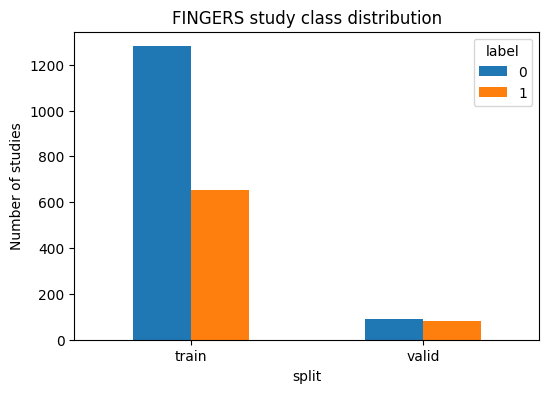

In [18]:
import matplotlib.pyplot as plt

counts = all_df.groupby(["split", "label"]).size().unstack()

counts.plot(kind="bar", figsize=(6,4))
plt.title("FINGERS study class distribution")
plt.ylabel("Number of studies")
plt.xticks(rotation=0)
plt.show()


In [19]:
import os
import csv

ROOT = "/kaggle/working/MURA_FINGERS_PREPROCESSED/MURA-v1.1"

def build_csv(split, out_csv):
    rows = []

    base = os.path.join(ROOT, split, "XR_FINGER")

    for patient in sorted(os.listdir(base)):
        patient_dir = os.path.join(base, patient)
        if not os.path.isdir(patient_dir):
            continue

        for study in sorted(os.listdir(patient_dir)):
            study_dir = os.path.join(patient_dir, study)
            if not os.path.isdir(study_dir):
                continue

            # Label from folder name
            if "positive" in study.lower():
                label = 1
            elif "negative" in study.lower():
                label = 0
            else:
                print("Skipping (no label in name):", study_dir)
                continue

            mura_path = f"MURA-v1.1/{split}/XR_FINGER/{patient}/{study}"
            rows.append([mura_path, label])

    # Save CSV
    with open(out_csv, "w", newline="") as f:
        writer = csv.writer(f)
        for r in rows:
            writer.writerow(r)

    print(f"{split}: {len(rows)} studies written → {out_csv}")


# Generate both
build_csv("train", "/kaggle/working/MURA_FINGERS_PREPROCESSED/train_labeled_studies.csv")
build_csv("valid", "/kaggle/working/MURA_FINGERS_PREPROCESSED/valid_labeled_studies.csv")

train: 1935 studies written → /kaggle/working/MURA_FINGERS_PREPROCESSED/train_labeled_studies.csv
valid: 175 studies written → /kaggle/working/MURA_FINGERS_PREPROCESSED/valid_labeled_studies.csv


# 4. Model Definition

In [20]:
!pip install torch torchvision tqdm pandas opencv-python

In [21]:
import os
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import cv2
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [22]:
DATA_ROOT = "/kaggle/working/MURA_FINGERS_PREPROCESSED/MURA-v1.1"
CSV_ROOT  = "/kaggle/working/MURA_FINGERS_PREPROCESSED"

TRAIN_CSV = os.path.join(CSV_ROOT, "train_labeled_studies.csv")
VALID_CSV = os.path.join(CSV_ROOT, "valid_labeled_studies.csv")

In [23]:
import os
import cv2
import torch
import pandas as pd
from torch.utils.data import Dataset

class MuraFINGERMIL(Dataset):
    def __init__(self, csv_file, split, DATA_ROOT, transform=None, df_override=None):
        """
        Args:
            csv_file (str): Path to the MURA csv (e.g., train_labeled_studies.csv)
            split (str): 'train' or 'valid'
            DATA_ROOT (str): Root directory where your preprocessed images are stored
            transform (callable, optional): PyTorch transforms to be applied
            df_override (pd.DataFrame, optional): Used for custom splitting or testing
        """
        self.data_root = DATA_ROOT
        self.split = split
        self.transform = transform
        
        if df_override is not None:
            self.df = df_override
        else:
            # Load CSV and filter ONLY for Finger X-rays
            self.df = pd.read_csv(csv_file, header=None, names=["study_path", "label"])
            self.df = self.df[self.df.study_path.str.contains("XR_FINGER")].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = torch.tensor(row.label, dtype=torch.float32)

        
        rel_path = row.study_path.replace("MURA-v1.1/", "")
        
       
        if rel_path.startswith(self.split):
            study_dir = os.path.join(self.data_root, rel_path)
        else:
            study_dir = os.path.join(self.data_root, self.split, rel_path)

      
        study_dir = study_dir.rstrip('/')

   
        images = []
        if not os.path.exists(study_dir):
            raise FileNotFoundError(f"❌ Could not find folder: {study_dir}\n"
                                    f"Check if DATA_ROOT is correct or if 'train/train' nesting exists.")

        
        for f in sorted(os.listdir(study_dir)):
            if f.endswith(".png"):
                img_path = os.path.join(study_dir, f)
                
               
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue
                
                
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
                
                if self.transform:
                    img = self.transform(img)
                images.append(img)

        if len(images) == 0:
            raise RuntimeError(f" No .png images found in: {study_dir}")

        # Stack list of [3, 224, 224] tensors into a single [N, 3, 224, 224] bag
        bag = torch.stack(images)   
        return bag, label

In [24]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
train_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((224,224)),
    T.RandomHorizontalFlip(p=0.5),  # safe
    T.RandomRotation(5),           # smaller rotation
    T.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    T.RandomAutocontrast(p=0.3),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
val_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])


# 5. Training

In [25]:
class AttentionMIL(nn.Module):
    def __init__(self):
        super().__init__()

        backbone = models.mobilenet_v2(pretrained=True)

        # Use only feature extractor
        self.feature_extractor = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.feat_dim = 1280   

        self.dropout = nn.Dropout(0.3)

        self.attention = nn.Sequential(
            nn.Linear(self.feat_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 1)
        )

        self.classifier = nn.Linear(self.feat_dim, 1)

    def forward(self, x):   # x = [1, N, 3, H, W]
        x = x.squeeze(0)    # [N, 3, H, W]

        feats = self.feature_extractor(x)
        feats = self.pool(feats).view(feats.size(0), -1)  # [N,1280]

        A = self.attention(feats)
        A = torch.softmax(A, dim=0)

        bag_feat = torch.sum(A * feats, dim=0)
        bag_feat = self.dropout(bag_feat)

        out = self.classifier(bag_feat)

        return out, A


In [26]:
import torch
# Dataset

train_ds = MuraFINGERMIL(
    csv_file=TRAIN_CSV, 
    split="train", 
    DATA_ROOT=DATA_ROOT, 
    transform=train_tf
)

valid_ds = MuraFINGERMIL(
    csv_file=VALID_CSV, 
    split="valid", 
    DATA_ROOT=DATA_ROOT, 
    transform=val_tf
)

# ----- Oversampling -----
from torch.utils.data import WeightedRandomSampler
import numpy as np


labels = train_ds.df["label"].values

class_sample_count = np.array([
    len(np.where(labels == 0)[0]),
    len(np.where(labels == 1)[0])
])

weight = 1. / class_sample_count
samples_weight = np.array([weight[t] for t in labels])
samples_weight = torch.from_numpy(samples_weight).double()

sampler = WeightedRandomSampler(
    samples_weight,
    num_samples=len(samples_weight),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=1, sampler=sampler)
val_loader   = DataLoader(valid_ds, batch_size=1, shuffle=False)

# Define device before its first use
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----- pos_weight for loss -----  ← ADD THIS BLOCK HERE
pos = (labels == 1).sum()
neg = (labels == 0).sum()
pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Class counts → Normal: {neg}, Abnormal: {pos}")
print(f"pos_weight: {pos_weight.item():.4f}")

Class counts → Normal: 1280, Abnormal: 655
pos_weight: 1.9542


In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)


In [28]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Updated folder for Finger checkpoints
CHECKPOINT_DIR = "/kaggle/working/MURA_FINGER_CHECKPOINTS"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

best_auc    = 0.0
start_epoch = 0
patience    = 7
no_improve  = 0

# MIL Bag Constraints
MAX_BAG_TRAIN = 8
MAX_BAG_VAL   = 12


model = AttentionMIL().to(device)

# 1. Differential Learning Rates: Slow backbone, faster heads
optimizer = torch.optim.AdamW([
    {'params': model.feature_extractor.parameters(), 'lr': 1e-5},
    {'params': model.attention.parameters(),         'lr': 1e-4},
    {'params': model.classifier.parameters(),        'lr': 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)


pos_weight = torch.tensor([1.97], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


resume_path = os.path.join(CHECKPOINT_DIR, "last_checkpoint_finger.pth")

if os.path.exists(resume_path):
    print(f"Loading checkpoint: {resume_path}")
    try:
        checkpoint = torch.load(resume_path, weights_only=False, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_auc    = checkpoint.get('best_auc', 0.0)
        no_improve  = checkpoint.get('no_improve', 0)
        print(f"Resuming from epoch {start_epoch}. Best AUC so far: {best_auc:.4f}")
    except Exception as e:
        print(f"Error loading checkpoint: {e}. Starting fresh.")
else:
    print("No checkpoint found. Starting fresh training.")


num_epochs = 20

for epoch in range(start_epoch, num_epochs):

    
    if epoch == 1:
        print("Unfreezing backbone (stable mode)...")
        for p in model.feature_extractor.parameters():
            p.requires_grad = True
        # Keep BatchNorm frozen in eval mode to prevent statistics drift
        for m in model.feature_extractor.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()
                m.requires_grad_(False)

    model.train()
   
    if epoch >= 1:
        for m in model.feature_extractor.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()

    train_loss = 0.0
    all_train_preds, all_train_labels = [], []

    for bags, label in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        bags, label = bags.to(device), label.to(device).float()

        # Bag-level Augmentation: Random subset
        if bags.size(1) > MAX_BAG_TRAIN:
            idx = torch.randperm(bags.size(1))[:MAX_BAG_TRAIN]
            bags = bags[:, idx]

        # Forward pass
        pred = model(bags)
        if isinstance(pred, tuple): pred = pred[0]

        # Flattening both to ensure shape [1] matches [1]
        loss = criterion(pred.view(-1), label.view(-1))

        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping for MIL stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()

    
    model.eval()
    val_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for bags, label in tqdm(val_loader, desc=f"Epoch {epoch+1} [Valid]"):
            bags, label = bags.to(device), label.to(device).float()

            if bags.size(1) > MAX_BAG_VAL:
                n = bags.size(1)
                start = (n - MAX_BAG_VAL) // 2
                bags = bags[:, start : start + MAX_BAG_VAL]

            pred = model(bags)
            if isinstance(pred, tuple): pred = pred[0]

            val_loss += criterion(pred.view(-1), label.view(-1)).item()
            all_preds.append(torch.sigmoid(pred).cpu().numpy())
            all_labels.append(label.cpu().numpy())

    # Compute Metrics
    all_preds  = np.concatenate(all_preds).ravel()
    all_labels = np.concatenate(all_labels).ravel()
    auc = roc_auc_score(all_labels, all_preds)

    print(f"\nSummary Epoch {epoch+1}:")
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")
    print(f"Val AUC: {auc:.4f} (Best: {max(auc, best_auc):.4f})")

    scheduler.step()

    
    checkpoint_state = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_auc': max(auc, best_auc),
        'no_improve': no_improve,
    }

    torch.save(checkpoint_state, os.path.join(CHECKPOINT_DIR, "last_checkpoint_finger.pth"))

    if auc > best_auc:
        best_auc = auc
        no_improve = 0
        torch.save(checkpoint_state, os.path.join(CHECKPOINT_DIR, "best_model_finger.pth"))
        print(f"--- 🏆 New Best AUC: {best_auc:.4f}! ---")
    else:
        no_improve += 1
        print(f"No improvement ({no_improve}/{patience})")
        if no_improve >= patience:
            print("Early stopping triggered.")
            break

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 97.5MB/s]


No checkpoint found. Starting fresh training.


Epoch 1 [Valid]: 100%|██████████| 175/175 [00:01<00:00, 96.71it/s]


...


Summary Epoch 18:
Train Loss: 1.0704 | Val Loss: 3.0244
Val AUC: 0.8109 (Best: 0.8363)
No improvement (5/7)


Epoch 19 [Valid]: 100%|██████████| 175/175 [00:01<00:00, 97.77it/s] 



Summary Epoch 19:
Train Loss: 0.8035 | Val Loss: 3.0627
Val AUC: 0.8219 (Best: 0.8363)
No improvement (6/7)


Epoch 20 [Valid]: 100%|██████████| 175/175 [00:01<00:00, 97.23it/s]



Summary Epoch 20:
Train Loss: 0.9042 | Val Loss: 3.1127
Val AUC: 0.8235 (Best: 0.8363)
No improvement (7/7)
Early stopping triggered.


# 6. Evaluation

✅ Loaded best model from epoch 20
Gathering predictions...


100%|██████████| 175/175 [00:01<00:00, 98.65it/s] 



       CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.74      0.75      0.75        92
    Positive       0.72      0.71      0.72        83

    accuracy                           0.73       175
   macro avg       0.73      0.73      0.73       175
weighted avg       0.73      0.73      0.73       175



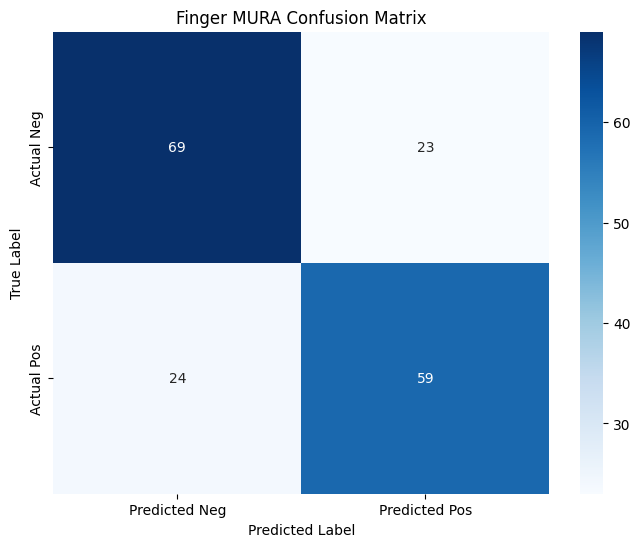


Final Validation AUC: 0.8235


In [29]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 1. Load the Best Model
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model_finger.pth")
if os.path.exists(best_model_path):
    checkpoint = torch.load(resume_path, weights_only=False, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Loaded best model from epoch {checkpoint['epoch']+1}")

model.eval()
all_preds = []
all_labels = []

# 2. Run Inference
print("Gathering predictions...")
with torch.no_grad():
    for bags, label in tqdm(val_loader):
        bags = bags.to(device)
        
        # Consistent validation subsetting
        if bags.size(1) > MAX_BAG_VAL:
            n = bags.size(1)
            start = (n - MAX_BAG_VAL) // 2
            bags = bags[:, start : start + MAX_BAG_VAL]
            
        pred = model(bags)
        if isinstance(pred, tuple): pred = pred[0]
        
        # Convert logits to probabilities and then to binary classes (0 or 1)
        prob = torch.sigmoid(pred).item()
        all_preds.append(prob)
        all_labels.append(label.item())

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_probs  = np.array(all_preds)
all_preds_binary = (all_probs > 0.5).astype(int)

# 3. Generate Classification Report
print("\n" + "="*30)
print("       CLASSIFICATION REPORT")
print("="*30)
print(classification_report(all_labels, all_preds_binary, target_names=['Negative', 'Positive']))

# 4. Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])
plt.title('Finger MURA Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 5. Final AUC Check
final_auc = roc_auc_score(all_labels, all_probs)
print(f"\nFinal Validation AUC: {final_auc:.4f}")

# 7. Export Checkpoints

In [30]:
import shutil

shutil.make_archive(
    "/kaggle/working/finger_checkpoints",  
    "zip",
    "/kaggle/working/MURA_FINGER_CHECKPOINTS" 
)

print("✅ Done! Download 'finger_checkpoints.zip' from the Output panel.")

✅ Done! Download 'finger_checkpoints.zip' from the Output panel.
